# D0 · Start here: what size_halo is, and your first run

**What you will learn**
- what this tool is for, in one paragraph and one picture;
- how to install it and run the baseline design;
- how to read the answer: the sized aircraft, *what sized it*, where the weight goes, and how the mission is flown;
- how the code is laid out, so the later tutorials have a map.

**Prerequisites:** the core tutorials help (`../00_orientation.ipynb` onwards); this deep dive reads the full reference top-down. Some Python, and the vocabulary of aircraft conceptual design (take-off weight, disk loading,
wing loading). Every term is in the [glossary](../GLOSSARY.md).

**Run time:** under a minute once the baseline is cached; about 10-15 minutes the very first time (the baseline solve).

### How every tutorial is organised

Each notebook teaches one part of the model through three lenses, because these are the questions a reviewer asks:

| Lens | The question it answers |
|---|---|
| **Why** | Why is it built this way, and what was tried and rejected? |
| **What it can't do** | Where does the model stop being trustworthy? |
| **What's next** | What would the next increment of fidelity or capability be? |

Code cells carry `check(...)` lines: each one verifies a claim the text makes, so if the code changes and a claim
stops being true, the notebook says so.

## 1. The tool in one paragraph

`size_halo` is a **conceptual sizing model** for an unmanned, **series-hybrid-electric tiltrotor** of the "Halo"
class (two proprotors on the wing tips, two turboshafts driving generators, a battery, electric motors turning the
rotors). It answers: *given what the aircraft must do (payload, range, speed, hover, failures), what is the lightest
aircraft that does it, and which requirement is the one that sizes each part?*

The defining design choice: **the aircraft, its powertrain and its mission are sized together in one gradient-based
optimization.** Every discipline model returns *equations* in the design variables; one AeroSandbox `Opti` problem
holds all of them; IPOPT solves them all at once, with exact derivatives from CasADi. There is no outer "converge the
weight" loop.

```
 requirements ──►┌────────────────────────── ONE asb.Opti problem (IPOPT) ──────────────────────────┐
                 │  design variables: MTOM, wing, tails, rotor, machines, battery, fuel, speeds ... │
                 │  equations from:  aerodynamics · rotor · powertrain · weights · stability ·      │──► sized aircraft
                 │                   thermal · mission segments · failure hovers                    │    + named binding
                 │  constraints:     mass closure, power balance, SOC chain, every margin >= 0      │      constraints
                 │  objective:       minimum take-off mass (or max payload, or min cost)            │
                 └──────────────────────────────────────────────────────────────────────────────────┘
                        │ afterwards (never fed back): conversion corridor, trajectories, OpenVSP/FE checks
```

> The inputs are illustrative engineering values from public sources (see `docs/HALO_REFERENCE.md`); this is not
> program data. The value of the tool is the *structure*: replacing an input with real data is meant to be a
> one-line change.

## 2. Install and run

From the repository root:

```bash
uv sync --group notebooks            # Python 3.13, AeroSandbox, CasADi/IPOPT, Jupyter
uv run jupyter lab tutorials          # then open this notebook
```

Everything else in the repo runs the same way (`uv run python -m examples.halo_sizing` prints the baseline). Set
`OMP_NUM_THREADS=1` if you run several solves at once: threaded BLAS under contention makes IPOPT fail spuriously.

The first cell of every tutorial puts `src/` (the package `aircraft_closure`), the repo root (for `examples/`) and
`tutorials/` on the path, and loads a few helpers.

In [1]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(repo_root / "tutorials"))
from tutorial_helpers import *          # paths, plot style, check(), lb(), baseline(), capture_opti()

## 3. The requirements

Requirements are plain frozen dataclasses. `HaloRequirements` says what the aircraft must do; `HaloAssumptions`
holds every engineering assumption and model switch (about 150 fields, each commented with its source). Both live in
`examples/halo_sizing.py`, the driver for this aircraft. Nothing is hidden in globals.

In [2]:
from dataclasses import fields
from examples.halo_sizing import HaloRequirements, HaloAssumptions

r = HaloRequirements()
print(f"payload            {r.mass_payload_kg:.0f} kg ({lb(r.mass_payload_kg):,.0f} lb)")
print(f"range              {r.range_m / 1852:.0f} nm, then a {r.duration_loiter_s / 60:.0f} min reserve loiter")
print(f"max speed          {r.velocity_max_m_s / u.knot:.0f} kt at {r.altitude_cruise_m / u.foot:,.0f} ft (sustained)")
print(f"ceiling            {r.altitude_ceiling_m / u.foot:,.0f} ft")
print(f"hover (OGE)        {r.altitude_hover_m / u.foot:,.0f} ft at T/W {r.thrust_to_weight_hover}")
print(f"hot-day hover      {r.altitude_hover_hot_m / u.foot:,.0f} ft at {(r.temperature_hover_hot_K - 273.15) * 9 / 5 + 32:.0f} F, "
      f"at the destination (end of mission mass)")
print(f"failure hovers     {r.duration_engine_out_hover_s:.0f} s (engine out; and with redundancy: bus out, string out)")
print(f"stall              <= {r.velocity_stall_max_m_s / u.knot:.0f} kt at CL_max {r.cl_max}")
a = HaloAssumptions()
print(f"\nfixed engines      {a.count_turbogenerators} x {a.power_rated_turboshaft_fixed_W / u.hp:,.0f} hp (bought, not designed)")
print(f"HaloAssumptions has {len(fields(HaloAssumptions))} fields; HaloRequirements has {len(fields(HaloRequirements))}")

payload            900 kg (1,984 lb)
range              445 nm, then a 20 min reserve loiter
max speed          210 kt at 10,000 ft (sustained)
ceiling            13,000 ft
hover (OGE)        4,000 ft at T/W 1.05
hot-day hover      4,000 ft at 95 F, at the destination (end of mission mass)
failure hovers     60 s (engine out; and with redundancy: bus out, string out)
stall              <= 120 kt at CL_max 1.5

fixed engines      2 x 1,120 hp (bought, not designed)
HaloAssumptions has 143 fields; HaloRequirements has 20


## 4. Run the baseline design

`baseline()` calls `examples.halo_sizing.solve_halo_sizing()` with every default, the "v3.6 baseline", and caches
the result in `tutorials/.cache/` (keyed on a hash of the source, so it re-solves if the code changes). Behind that
one call are several complete solves: a ladder of simpler *precursor* problems to get a good starting point, a
solve with continuous machine counts, then a final solve with whole machines. Core tutorials 19 and 20 take that apart.

In [3]:
ref = baseline()
d = ref.design
print(f"take-off mass   {ref.mass_takeoff_kg:,.0f} kg  = {lb(ref.mass_takeoff_kg):,.0f} lb")
print(f"empty mass      {ref.mass_empty_kg:,.0f} kg  = {lb(ref.mass_empty_kg):,.0f} lb  (includes the battery)")
print(f"fuel loaded     {ref.mass_fuel_kg:,.0f} kg  (1.1 x the {ref.mass_fuel_burnt_kg:,.0f} kg burnt)")
print(f"battery         {ref.energy_battery_kWh:.1f} kWh, {d.count_parallel_battery:.1f} parallel strings of 210 cells")
print(f"wing            {d.area_wing_m2:.1f} m2, span {ref.span_m:.2f} m, W/S {ref.wing_loading_kg_m2:.0f} kg/m2")
print(f"rotors          2 x {2 * ref.radius_rotor_m:.2f} m diameter, disk loading {ref.disk_loading_kg_m2:.1f} kg/m2 "
      f"({ref.disk_loading_kg_m2 * u.kg / u.lbm * u.foot**2:.1f} lb/ft2), tip speed {d.speed_tip_m_s:.0f} m/s")
print(f"cruise          {ref.velocity_cruise_m_s / u.knot:.0f} kt, L/D {ref.lift_to_drag_cruise:.1f}")
print(f"machines        motor lanes of {ref.machine_units['motor'][1]} units, generators of {ref.machine_units['generator'][1]} units")
print(f"smallest margin {ref.min_margin:.1e}  (>= 0 means every requirement is met)")
check("baseline reproduces the documented v3.6 take-off weight, 15,179 lb", abs(lb(ref.mass_takeoff_kg) - 15179) < 5)
check("every margin is satisfied (to solver tolerance)", ref.min_margin > -1e-6)
check("mass closes: take-off mass equals the sum of the parts", abs(ref.closure_residual_kg) < 1e-3)

take-off mass   6,885 kg  = 15,179 lb
empty mass      5,049 kg  = 11,130 lb  (includes the battery)
fuel loaded     936 kg  (1.1 x the 851 kg burnt)
battery         70.0 kWh, 23.0 parallel strings of 210 cells
wing            23.3 m2, span 11.94 m, W/S 296 kg/m2
rotors          2 x 9.66 m diameter, disk loading 46.9 kg/m2 (9.6 lb/ft2), tip speed 238 m/s
cruise          165 kt, L/D 9.1
machines        motor lanes of 2 units, generators of 3 units
smallest margin -9.8e-09  (>= 0 means every requirement is met)
PASS  baseline reproduces the documented v3.6 take-off weight, 15,179 lb
PASS  every margin is satisfied (to solver tolerance)
PASS  mass closes: take-off mass equals the sum of the parts


## 5. What sized the aircraft

An optimizer pushes until something stops it. The constraints that stop it are **binding** (margin = 0): they are the
requirements that size each part. The result lists them by name, which is one of the most useful outputs of the
tool: it says *why* each part is the size it is.

In [4]:
plain = {
    "battery end voltage_V": "battery: cell voltage cutoff at the end of the engine-out hover (sag, not energy, sizes the pack)",
    "turboshaft power_shaft_W": "turboshaft at full power available (fixed engines are used to the limit)",
    "generator_gearbox power_input_W": "generator step-up gearbox at its rating",
    "generator torque_Nm": "generator at its maximum torque (engine-out hover sizes the generators)",
    "motor torque_Nm": "motor lane at maximum torque in the bus-out hover (sizes the motors)",
    "propulsor power_shaft_W": "rotor at its maximum shaft power in the 4,000 ft hover",
    "gearbox power_input_W": "rotor gearbox at its rating in the 4,000 ft hover",
    "heat_exchanger power_heat_W": "heat exchanger: heat rejection on the hot day (sizes the cooler)",
    "rotor_radius_m": "rotor radius capped by the space between fuselage and wing tip",
    "static_margin": "longitudinal static margin >= 10 % (sizes the horizontal tail)",
    "cn_beta_per_rad": "directional stability Cn_beta >= 0.06 /rad (sizes the vertical tail)",
}
for label in ref.binding:
    point, _, what = label.rpartition(": ")
    print(f"{(point or 'design'):<22} {plain.get(what, what)}")

design                 rotor radius capped by the space between fuselage and wing tip
engine-out hover 3/3   battery: cell voltage cutoff at the end of the engine-out hover (sag, not energy, sizes the pack)
hot-day hover          heat exchanger: heat rejection on the hot day (sizes the cooler)
engine-out hover 3/3   turboshaft at full power available (fixed engines are used to the limit)
engine-out hover 3/3   generator step-up gearbox at its rating
hover                  rotor at its maximum shaft power in the 4,000 ft hover
hover                  rotor gearbox at its rating in the 4,000 ft hover
engine-out hover 1/3   turboshaft at full power available (fixed engines are used to the limit)
engine-out hover 1/3   generator step-up gearbox at its rating
hot-day hover          turboshaft at full power available (fixed engines are used to the limit)
engine-out hover 2/3   turboshaft at full power available (fixed engines are used to the limit)
engine-out hover 2/3   generator step-up gea

**Reading it.** The two-minute version of the whole design:

- **Battery:** the engine-out hover. The pack must keep the bus above the cell cutoff (210 × 2.5 V = 525 V) at the
  *end* of 60 s on one turbogenerator, starting from the 30 % reserve. Voltage sag, not stored energy, sets its size.
- **Generators and their gearboxes:** the engine-out hover, where one turbogenerator runs flat out.
- **Motors:** the bus-out hover, where one of the two motor lanes on each rotor carries all the torque.
- **Rotors and drive:** the 4,000 ft hover; the rotor diameter is capped by the span.
- **Heat exchanger:** the hot-day hover at the destination.
- **Tails:** static margin and directional stability.

Some limits also sit on **variable bounds**, which the `binding` list does not show (it lists named margins only):

In [5]:
from examples.halo_sizing import HaloAssumptions
at_bounds = {
    "solidity (lower bound 0.06)": abs(d.solidity - 0.06) < 1e-6,
    "hover blade loading CT/sigma (limit 0.14)": abs(ref.hovers[0].blade_loading - 0.14) < 1e-6,
}
for name, active in at_bounds.items():
    print(f"{'AT BOUND ' if active else 'free     '} {name}")
check("solidity sits on its 0.06 lower bound", at_bounds["solidity (lower bound 0.06)"])

AT BOUND  solidity (lower bound 0.06)
AT BOUND  hover blade loading CT/sigma (limit 0.14)
PASS  solidity sits on its 0.06 lower bound


That is worth noticing early: the optimizer wants an even lower solidity (less profile power) but the hover blade
loading limit CT/σ ≤ 0.14 and the solidity bound stop it. deep dive D3 explains why those limits, not physics, set
parts of the rotor design.

## 6. Where the weight goes

PASS  the groups add up to the empty mass
powertrain 6,329 lb = 57% of the empty weight


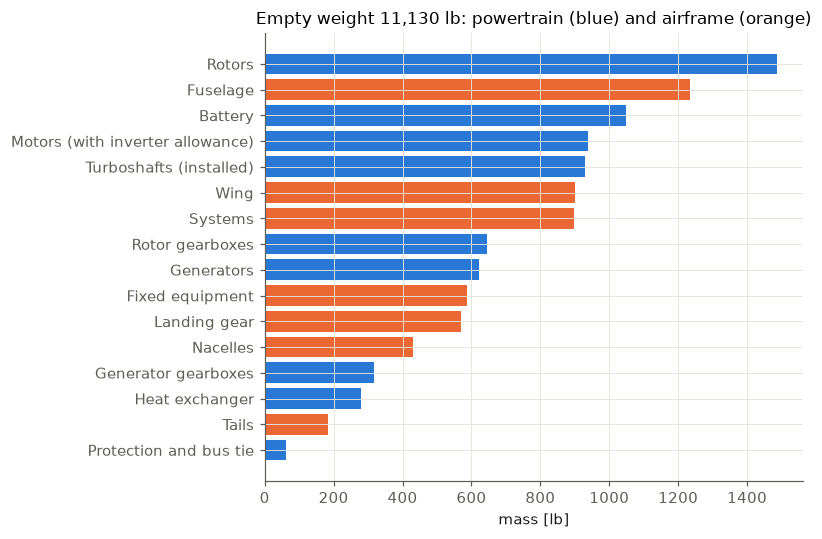

In [6]:
c, p = dict(ref.component_masses_kg), dict(ref.powertrain_masses_kg)
groups = {
    "Rotors": p["propulsor"], "Motors (with inverter allowance)": p["motor"],
    "Battery": p["battery"], "Turboshafts (installed)": p["turboshaft"],
    "Rotor gearboxes": p["gearbox"], "Generators": p["generator"], "Generator gearboxes": p["generator_gearbox"],
    "Heat exchanger": p["heat_exchanger"],
    "Protection and bus tie": p["protection_string"] + p["protection_bus_tie"] + p["cable_bus_tie"],
    "Fuselage": c["fuselage"], "Wing": c["wing"], "Systems": c["systems"], "Fixed equipment": c["equipment"],
    "Landing gear": c["landing_gear"], "Nacelles": c["nacelles"], "Tails": c["horizontal_tail"] + c["vertical_tail"],
}
oew = sum(groups.values())
check("the groups add up to the empty mass", abs(oew - ref.mass_empty_kg) < 1e-3)
powertrain = sum(groups[k] for k in list(groups)[:9])
print(f"powertrain {lb(powertrain):,.0f} lb = {powertrain / oew:.0%} of the empty weight")
names, masses = zip(*sorted(groups.items(), key=lambda item: item[1]))
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh(names, [lb(m) for m in masses],
        color=[blue if n in list(groups)[:9] else orange for n in names])
ax.set(xlabel="mass [lb]", title=f"Empty weight {lb(oew):,.0f} lb: powertrain (blue) and airframe (orange)")
plt.tight_layout(); plt.show()

## 7. How the mission is flown

The design mission is a series of **segments**, each one quasi-steady operating point (cruise is split into four so
the battery voltage can follow its state of charge). In every segment the optimizer also chooses the **energy
split**: the battery share of the electrical power, `hybridization` (negative = the generators recharge the pack).

In [7]:
print(f"{'segment':<16}{'min':>6}{'fuel kg':>9}{'SOC end':>9}")
for s in ref.segments:
    print(f"{s['label']:<16}{s['duration_s'] / 60:6.1f}{s['fuel_kg']:9.1f}{s['soc_end']:9.3f}")
print("\nbattery power per sub-segment (cruise is split in four; negative = the generators recharge the pack):")
for row in ref.battery_trace:
    print(f"   {row['label']:<16}{row['power_W'] / 1e3:8.1f} kW   SOC {row['soc_start']:.3f} -> {row['soc_end']:.3f}")
check("the pack is recharged in flight somewhere in the mission", min(row["power_W"] for row in ref.battery_trace) < 0)
check("landing state of charge stays at or above the 0.30 reserve", ref.soc_end >= 0.30 - 1e-6)

segment            min  fuel kg  SOC end
take-off hover     1.0      7.5    0.928
climb              8.5     53.5    0.756
cruise           143.9    667.0    0.471
reserve loiter    20.0     84.4    0.527
descent           10.2     32.6    0.466
landing hover      1.0      6.3    0.435

battery power per sub-segment (cruise is split in four; negative = the generators recharge the pack):
   take-off hover      99.6 kW   SOC 0.950 -> 0.928
   climb               91.8 kW   SOC 0.928 -> 0.756
   cruise 1/4          -7.4 kW   SOC 0.756 -> 0.815
   cruise 2/4           3.8 kW   SOC 0.815 -> 0.785
   cruise 3/4          15.7 kW   SOC 0.785 -> 0.658
   cruise 4/4          22.3 kW   SOC 0.658 -> 0.471
   reserve loiter     -11.8 kW   SOC 0.471 -> 0.527
   descent             25.1 kW   SOC 0.527 -> 0.466
   landing hover      128.0 kW   SOC 0.466 -> 0.435
PASS  the pack is recharged in flight somewhere in the mission
PASS  landing state of charge stays at or above the 0.30 reserve


The battery helps in hover and climb, the generators top it up early in cruise and in the loiter, and it gives
energy back late in cruise and in the landing hover. The pack must land at or above 30 % state of charge, because that is where the engine-out reserve hover
starts.

## 8. A map of the code

```
src/aircraft_closure/           the reusable framework (never imports examples/)
  core/          typed ports, topology (instances, buses, counts), normalized margins
  powertrain/    motor, generator, battery (constant and equivalent-circuit), turboshaft, gearbox, rotor,
                 converters, cables, protection; machine database; redundancy; series-hybrid builder
  aerodynamics/  simple polar, AeroBuildup wrapper, Scholz hand build-up, blown wing, trim drag, hover download
  vehicle/       wing, tails, fuselage, gear, systems, payload, fuel; Aircraft = mass and CG aggregation
  weights/       AFDD rotorcraft weight equations (rotor, drive, engine section)
  controls/      static margin, directional stability
  thermal/       heat loads, lumped machine temperatures, ram-air heat exchanger
  performance/   build_flight_point: ONE operating point coupling aero + rotor + powertrain + thermal
  mission/       segments (hover, climb, cruise, loiter, descent), the SOC/fuel chain, cost per mission
  requirements/  capability requirements as flight conditions
  trajectory/    conversion corridor and direct-collocation trajectories (run after sizing)
  export/openvsp OpenVSP geometry, VSPAERO, CalculiX and Nastran decks (optional checks, never in sizing)
examples/        drivers: halo_sizing.py (THE aircraft), XV-15 and JVX validation, studies
notebooks/       six executed discipline notebooks (verification, 458 checks)
docs/            results, architecture, next steps, aircraft versions, design log (docs/decisions/001-039)
tutorials/       you are here
```

Two rules hold everywhere, and most "why" questions trace back to them:

1. **Components build equations; the caller owns optimization.** A motor returns its losses as expressions of speed,
   torque and voltage; it never creates a variable, clips, or iterates. Whoever builds the problem owns variables,
   constraints and the objective (`docs/OPTIMIZATION_PHILOSOPHY.md`).
2. **Dependencies point down.** Sizing → aircraft → disciplines → components → data. Lower layers never import
   higher ones, so every component can be tested alone.

## Why it is built this way

- **One problem, solved all at once.** A traditional sizing code iterates: guess the weight, size the parts, add them
  up, repeat. Here mass closure is a single equality, `MTOM / Σ parts = 1`, and it sits next to the power balances,
  the battery state-of-charge chain and every margin in one NLP. IPOPT closes them together with exact derivatives,
  so the answer is a true optimum of everything at once (not a converged point of a fixed design), and the
  constraints that stop the optimizer come out by name. deep dive D1 shows the difference on a toy problem.
- **Why AeroSandbox.** It gives symbolic NumPy (write physics once, evaluate it with numbers or with CasADi
  variables), an `Opti` front-end to IPOPT, atmosphere, AeroBuildup aerodynamics, airfoils and dynamics models.
  The framework composes it rather than re-implementing it (`docs/ARCHITECTURE.md`).
- **Requirements and missions are separate.** Capability requirements (hover at 4,000 ft, 210 kt, ceiling,
  failure hovers) are single points at maximum weight; the mission is what is flown to burn fuel and battery.
- **Keep the simplest model.** Every higher-fidelity model sits behind the same interface as the simpler one it
  replaced, and both stay switchable. So the effect of each model on the answer is traceable (the version history in
  the README is exactly that trace).

## What it can't do (at the tool level)

- It is **conceptual sizing**: quasi-steady points, handbook-calibrated weights, a calibrated analytic rotor. It sets
  targets and finds what drives the design; it does not certify anything. Wing strength at ultimate load, for one, is
  not yet demonstrated (deep dive D7).
- It is **local** optimization. IPOPT finds a local optimum from a starting point; the starting-point strategy
  (core tutorial 20) makes that robust, not global.
- It has **no detailed geometry in the loop**: no internal layout, no CAD-level outer mould line. OpenVSP export and
  finite-element decks run afterwards as checks.
- Performance is at the design mission only: no payload-range diagram yet.

## What's next (at the tool level)

The README frames the next steps as **work packages handed to specialist teams**, each replacing an input or a
calibrated model with better data, without restructuring the model: supplier data for machines, cells and the
engine; blade-element rotor maps; validated drag; Nastran strength, buckling and flutter; linear models at the trim
points and 6-DOF simulation; weight control with growth allowance carried inside the sizing. The README's work packages and `docs/NEXT_STEPS.md` consolidate them.

## Check yourself

<details><summary>1. Which requirement sizes the battery, and why is it not the mission energy?</summary>

The engine-out hover: 60 s on one turbogenerator at full weight, starting at the 30 % reserve. At low state of
charge the cell voltage is low and its resistance high, so the pack voltage sags hardest exactly there; the end
voltage must stay above 525 V. Adding parallel strings lowers resistance, so the pack grows until the sag fits. It
then holds more energy than the mission needs.
</details>

<details><summary>2. What does "binding" mean, and why do some limits not appear in the binding list?</summary>

A binding constraint is satisfied with zero margin at the optimum: relaxing it would let the objective improve. The
list shows named margins only. Limits written as variable bounds (solidity ≥ 0.06) or as direct constraints in the
flight point (CT/σ ≤ 0.14) can also be active without being listed.
</details>

<details><summary>3. Why is the cruise speed 165 kt when the requirement is 210 kt?</summary>

210 kt is a *capability* requirement (a separate flight point at maximum weight). The mission cruise speed is a
design variable chosen to minimize take-off mass; slower than 210 kt burns less fuel per mile for this aircraft.
</details>

In [8]:
check_summary()

7 of 7 checks passed
